In [146]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [147]:
# ==============================
# 2. LOAD DATASET
# ==============================

data = pd.read_csv('loan_approval_dataset.csv')   # Change filename if needed

print("First 5 rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

First 5 rows:
   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0           

In [148]:
data

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [149]:
data.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [150]:
data.shape

(4269, 13)

In [151]:
# data['loan_status'].value_counts()

In [152]:
data.isna().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [153]:
# Remove extra spaces from column names
data.columns = data.columns.str.strip()

print("Columns after cleaning:")
print(data.columns)

Columns after cleaning:
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [154]:
print(data["loan_status"].unique())

[' Approved' ' Rejected']


In [155]:
data["loan_status"].unique()

array([' Approved', ' Rejected'], dtype=object)

In [156]:
data["loan_status"] = (
    data["loan_status"]
    .str.strip()
    .str.lower()
)

In [157]:
data["loan_status"].unique()

array(['approved', 'rejected'], dtype=object)

In [158]:
data["loan_status"] = data["loan_status"].map({
    "approved": 1,
    "rejected": 0
})

In [159]:
data["loan_status"]

0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

# Feature Engineering

In [160]:
data['loan_income_ratio'] = data['loan_amount'] / data['income_annum']
data['emi_estimate'] = data['loan_amount'] / data['loan_term']
data['emi_estimate_ratio'] = data['emi_estimate'] / data['income_annum']
data['total_assets'] = data['residential_assets_value'] + data['commercial_assets_value'] + data['luxury_assets_value'] + data['bank_asset_value']
data['loan_asset_ratio'] = data['loan_amount'] / data['total_assets']

In [161]:
conditions = [
    (data['cibil_score'] <= 550),
    (data['cibil_score'] > 550) & (data['cibil_score'] <= 650),
    (data['cibil_score'] > 650) & (data['cibil_score'] <= 750),
    (data['cibil_score'] > 750),
]

values = ['High Risk', 'Medium Risk', 'Low Risk', 'Very Safe']

data['risk_category'] = np.select(conditions, values, default='Medium Risk')

In [162]:
data = data.drop(columns=["loan_id"])

# Encoding

In [163]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['education'] = le.fit_transform(data['education'])
data['self_employed'] = le.fit_transform(data['self_employed'])
data['loan_status'] = le.fit_transform(data['loan_status'])
data['risk_category'] = le.fit_transform(data['risk_category'])

In [164]:
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_income_ratio,emi_estimate,emi_estimate_ratio,total_assets,loan_asset_ratio,risk_category
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,3.114583,2.491667e+06,0.259549,50700000,0.589744,3
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,2.975610,1.525000e+06,0.371951,17000000,0.717647,0
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,3.263736,1.485000e+06,0.163187,57700000,0.514731,0
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.743902,3.837500e+06,0.467988,52700000,0.582543,0
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,2.469388,1.210000e+06,0.123469,55000000,0.440000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,2.300000,1.916667e+05,0.191667,7400000,0.310811,0
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,3.424242,5.650000e+05,0.171212,20000000,0.565000,2
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,3.676923,1.327778e+06,0.204274,39000000,0.612821,0
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,3.121951,1.600000e+06,0.390244,28800000,0.444444,3


In [165]:
list = ['loan_income_ratio', 'emi_estimate', 'emi_estimate_ratio', 'risk_category', 'cibil_score', 'loan_term', 'loan_status']

In [166]:
df = data[list]

In [167]:
# df['risk_category']

In [168]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [170]:
model = Pipeline([
    ("classifier", LogisticRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.9484777517564403
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       323
           1       0.96      0.96      0.96       531

    accuracy                           0.95       854
   macro avg       0.94      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854



In [171]:
model.score(X_train, y_train)
model.score(X_test, y_test)

0.9484777517564403

In [172]:
rf_model = Pipeline([
    ("classifier", RandomForestClassifier(
        max_depth= None,
        min_samples_leaf= 1,
        min_samples_split= 5,
        n_estimators= 100
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9953161592505855
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       323
           1       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      0.99      1.00       854
weighted avg       1.00      1.00      1.00       854



In [173]:
X_train

,loan_income_ratio,emi_estimate,emi_estimate_ratio,risk_category,cibil_score,loan_term
1877,2.979167,2.383333e+06,0.496528,3,795,6
1729,2.879310,9.277778e+05,0.159962,2,633,18
164,2.753086,1.238889e+06,0.152949,1,737,18
2298,3.159091,2.316667e+06,0.526515,3,810,6
2461,3.815385,3.100000e+06,0.476923,3,779,8
...,...,...,...,...,...,...
1386,2.424242,1.000000e+06,0.151515,0,379,16
2913,2.600000,7.222222e+04,0.144444,3,762,18
4072,3.377358,8.950000e+06,1.688679,2,580,2
361,3.204545,7.050000e+06,1.602273,0,349,2


In [174]:
rf_model.score(X_train, y_train)

0.9976573938506589

In [175]:
rf_model.score(X_test, y_test)

0.9953161592505855

In [186]:
import joblib

# joblib.dump(model, "best_loan_approval_model.pkl")

## Optional Work

In [177]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [178]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [179]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.9836
Decision Tree Accuracy: 0.9918
Random Forest Accuracy: 0.9953
KNN Accuracy: 0.6557
SVM Accuracy: 0.6218
Naive Bayes Accuracy: 0.9496
Gradient Boosting Accuracy: 0.9953


In [180]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
}).sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy
2        Random Forest  0.995316
6    Gradient Boosting  0.995316
1        Decision Tree  0.991803
0  Logistic Regression  0.983607
5          Naive Bayes  0.949649
3                  KNN  0.655738
4                  SVM  0.621780


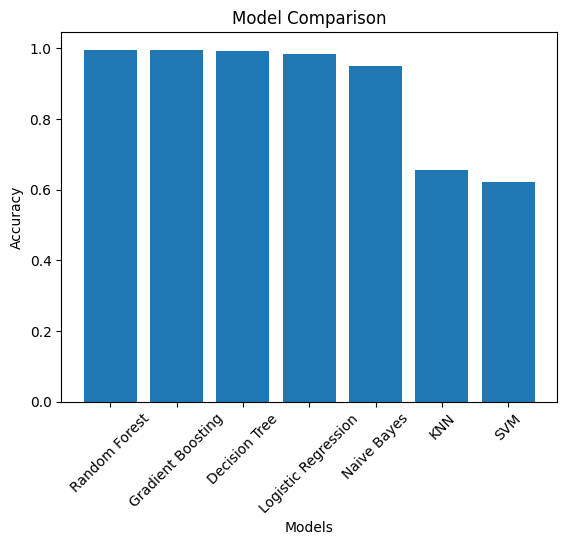

In [181]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [182]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X, y)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF Accuracy:", rf_grid.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best RF Accuracy: 0.9962523782983876


In [183]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid.fit(X, y)

print("Best GB Params:", gb_grid.best_params_)
print("Best GB Accuracy:", gb_grid.best_score_)

Best GB Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best GB Accuracy: 0.9962523782983876


In [184]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

svm_params = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X, y)

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM Accuracy:", svm_grid.best_score_)

Best SVM Params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best SVM Accuracy: 0.9925042074946943


In [185]:
print("Random Forest:", rf_grid.best_score_)
print("Gradient Boosting:", gb_grid.best_score_)
print("SVM:", svm_grid.best_score_)

Random Forest: 0.9962523782983876
Gradient Boosting: 0.9962523782983876
SVM: 0.9925042074946943
